In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/plantdisease


✅ Dataset downloaded to: /kaggle/input/plantdisease/PlantVillage

🔁 Processing original images...
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1772s 3s/step - accuracy: 0.4791 - loss: 1.7137 - val_accuracy: 0.7623 - val_loss: 0.6953
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1738s 3s/step - accuracy: 0.8408 - loss: 0.4624 - val_accuracy: 0.8649 - val_loss: 0.4109
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1720s 3s/step - accuracy: 0.9193 - loss: 0.2395 - val_accuracy: 0.8906 - val_loss: 0.3354
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1741s 3s/step - accuracy: 0.9596 - loss: 0.1242 - val_accuracy: 0.8535 - val_loss: 0.4954
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1734s 3s/step - accuracy: 0.9673 - loss: 0.0978 - val_accuracy: 0.8753 - val_loss: 0.4668
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1756s 3s/step - accuracy: 0.9677 - loss: 0.0935 - val_accuracy: 0.8993 - val_loss: 0.4250
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1726s 3s/step - accuracy: 0.9895 - loss: 0.0363 - val_accuracy: 0.8566 - val_loss: 0.5571
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1722s 3s/step - accuracy: 0.9820 - loss: 0.0558 - 

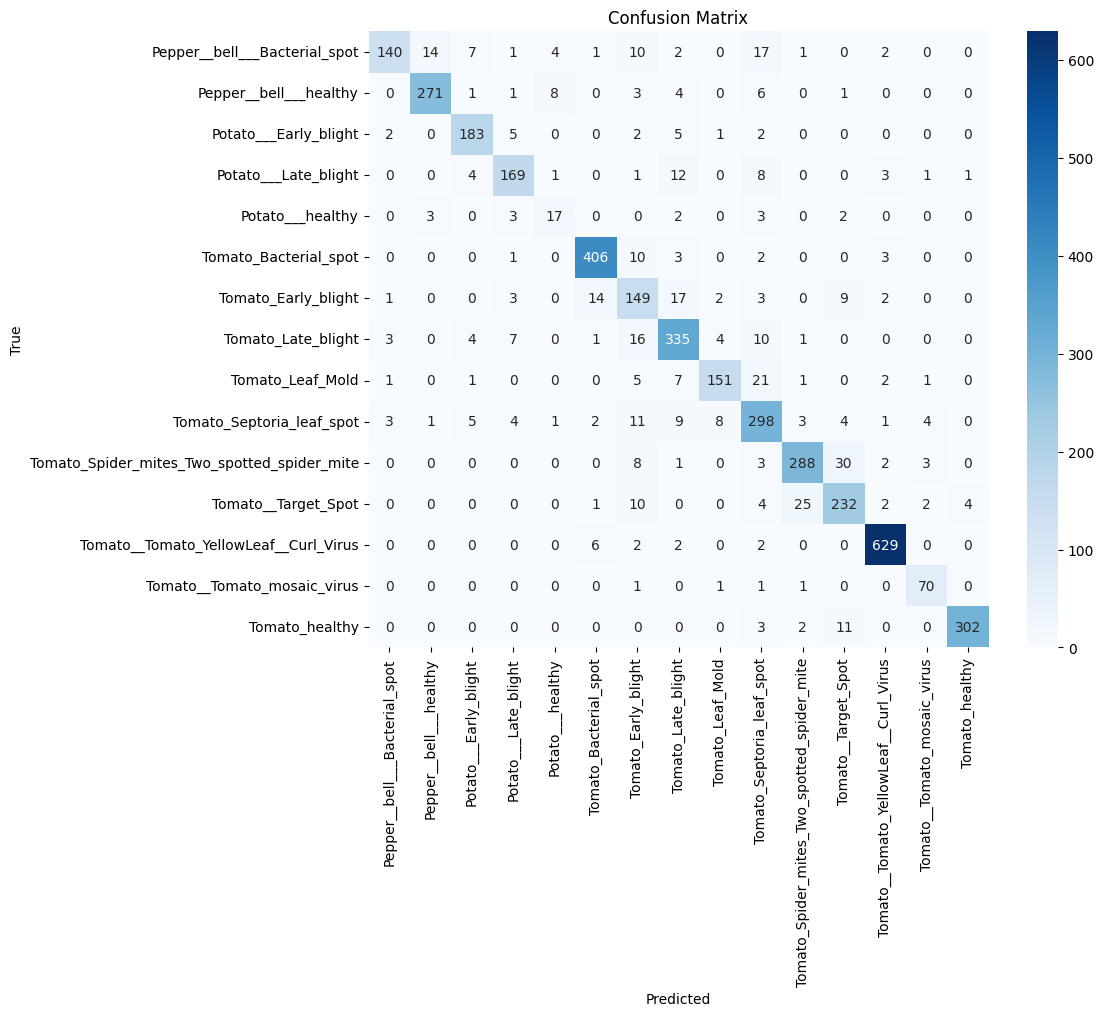


🔍 Edge-Detected Image Model Evaluation:
129/129 ━━━━━━━━━━━━━━━━━━━━ 127s 987ms/step

📊 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.58      0.42      0.49       199
                     Pepper__bell___healthy       0.64      0.81      0.72       295
                      Potato___Early_blight       0.73      0.60      0.66       200
                       Potato___Late_blight       0.53      0.56      0.54       200
                           Potato___healthy       0.21      0.20      0.21        30
                      Tomato_Bacterial_spot       0.71      0.89      0.79       425
                        Tomato_Early_blight       0.33      0.14      0.20       200
                         Tomato_Late_blight       0.61      0.55      0.58       381
                           Tomato_Leaf_Mold       0.48      0.43      0.45       190
                  Tomato_Septoria_lea

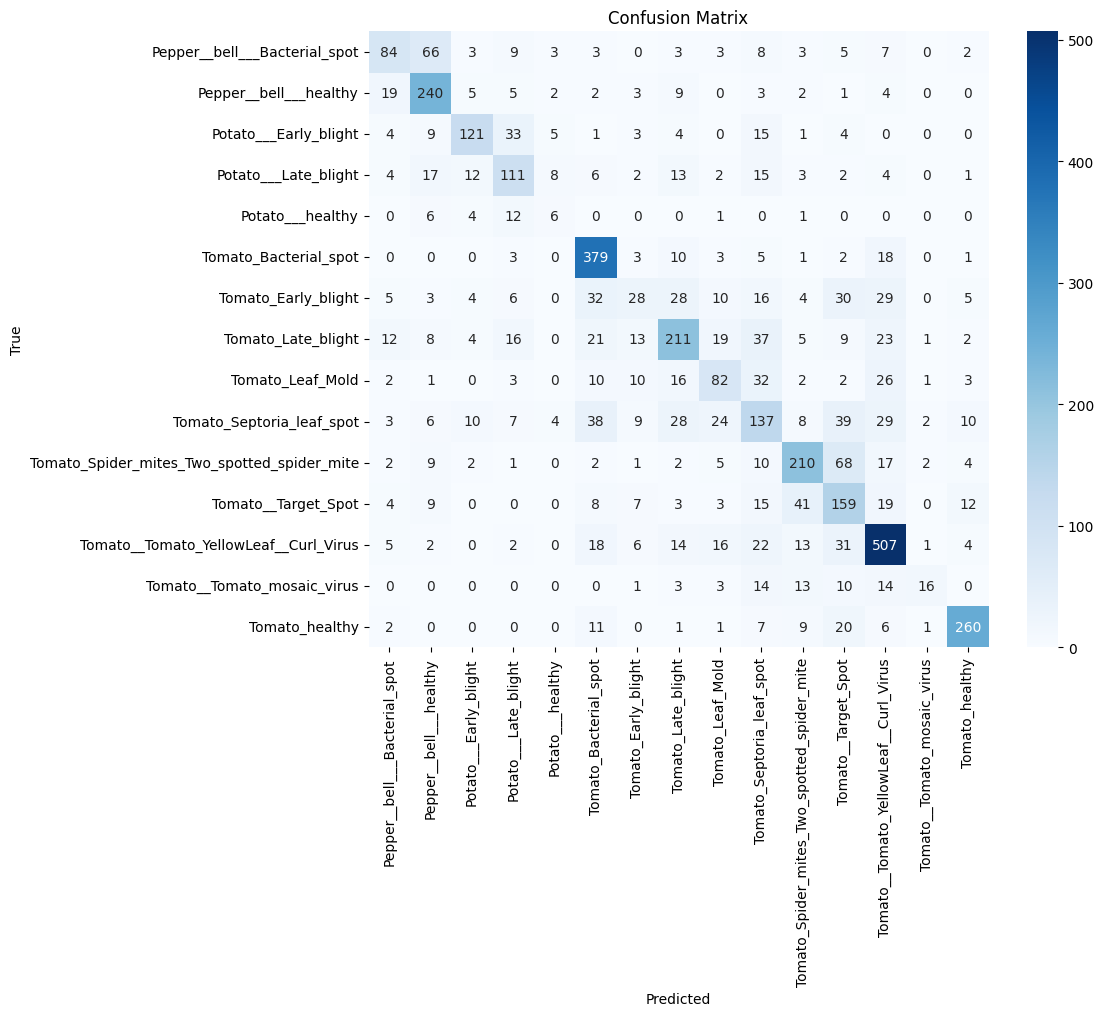

<ipython-input-1-b213589877de>:143: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-b213589877de>:143: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


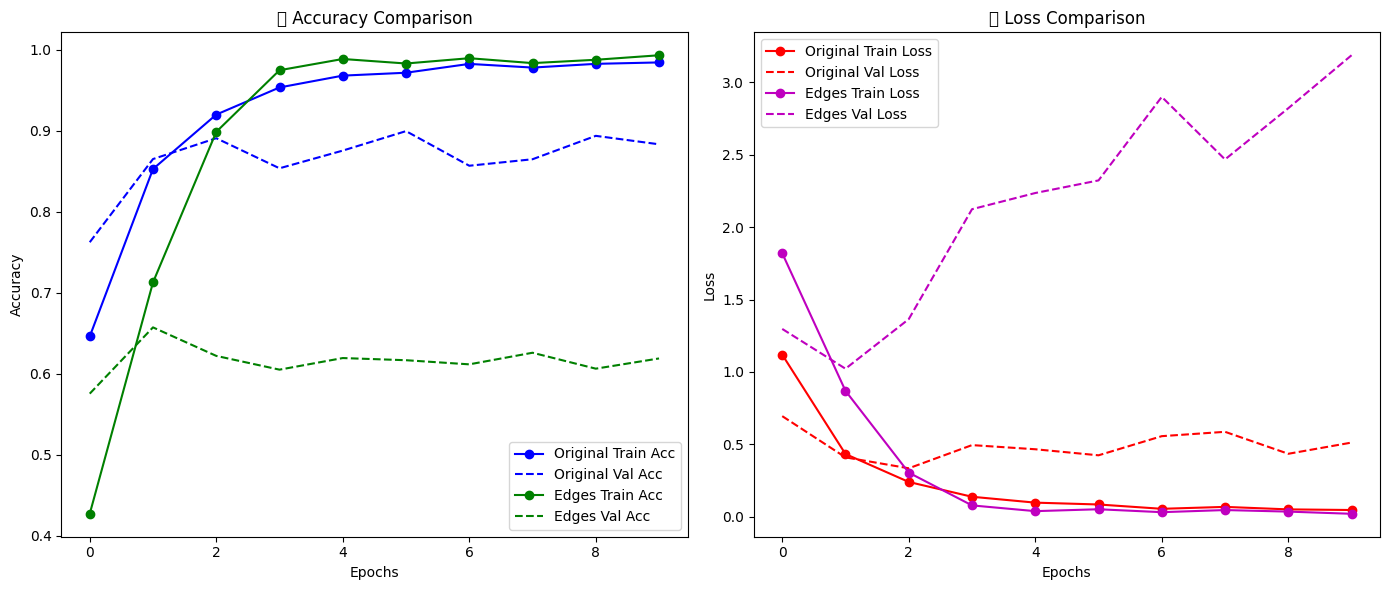


🖼️ Predictions on Original Images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step


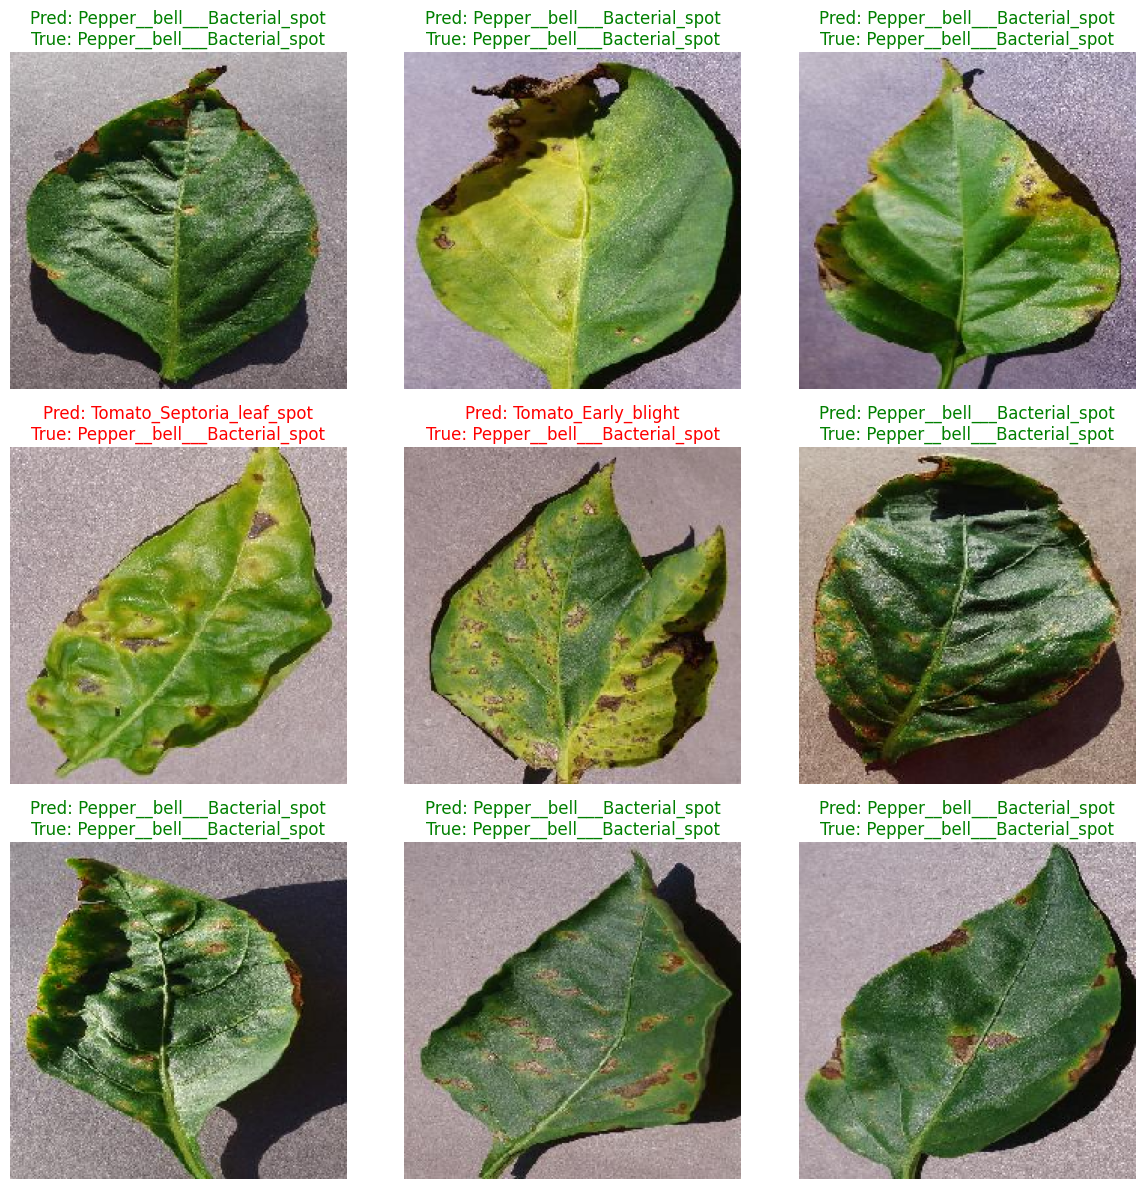


🖼️ Predictions on Edge-Detected Images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


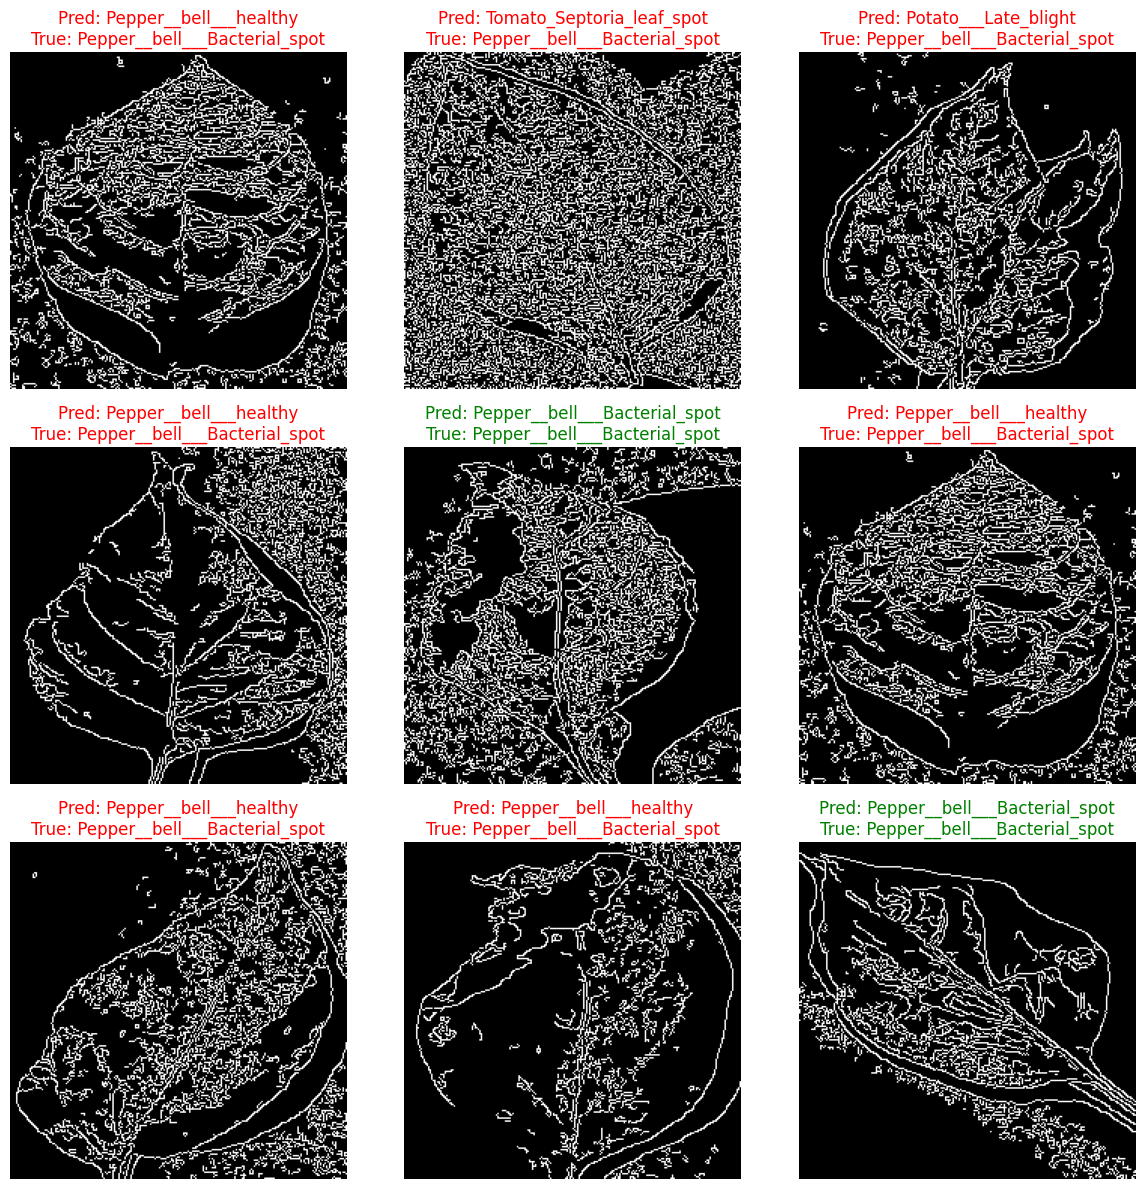

In [1]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

# Step 1: Download and prepare dataset from KaggleHub
def download_dataset():
    path = kagglehub.dataset_download("emmarex/plantdisease")
    data_dir = os.path.join(path, "PlantVillage")
    print(f"✅ Dataset downloaded to: {data_dir}")
    return data_dir

# Edge detection preprocessing
def apply_edge_detection(image):
    image = image.astype('uint8')
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    return cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

def preprocess_with_edges(image):
    image = tf.keras.preprocessing.image.img_to_array(image)
    image = tf.image.resize(image, (224, 224)).numpy().astype('uint8')
    edge_image = apply_edge_detection(image)
    return edge_image / 255.0

# Step 2: Prepare data generators
def create_data_generators(data_dir, img_size=(224, 224), batch_size=32, preprocess_func=None):
    datagen = ImageDataGenerator(
        rescale=None if preprocess_func else 1./255,
        preprocessing_function=preprocess_func,
        validation_split=0.2
    )

    train_gen = datagen.flow_from_directory(
        data_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        data_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )

    return train_gen, val_gen

# Step 3: Build a CNN model
def build_model(input_shape, num_classes):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 4: Train the model
def train_model(model, train_gen, val_gen, epochs=10):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs
    )
    return history

# Step 5: Evaluate the model
def evaluate_model(model, val_gen):
    val_gen.reset()
    predictions = model.predict(val_gen)
    y_pred = predictions.argmax(axis=1)
    y_true = val_gen.classes

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(val_gen.class_indices.keys())))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=val_gen.class_indices.keys(),
                yticklabels=val_gen.class_indices.keys(),
                cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 📈 Compare training histories
def plot_comparison_history(history1, history2, label1='Original', label2='Edges'):
    acc1 = history1.history['accuracy']
    val_acc1 = history1.history['val_accuracy']
    loss1 = history1.history['loss']
    val_loss1 = history1.history['val_loss']

    acc2 = history2.history['accuracy']
    val_acc2 = history2.history['val_accuracy']
    loss2 = history2.history['loss']
    val_loss2 = history2.history['val_loss']

    epochs = range(len(acc1))

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc1, 'bo-', label=f'{label1} Train Acc')
    plt.plot(epochs, val_acc1, 'b--', label=f'{label1} Val Acc')
    plt.plot(epochs, acc2, 'go-', label=f'{label2} Train Acc')
    plt.plot(epochs, val_acc2, 'g--', label=f'{label2} Val Acc')
    plt.title('📈 Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss1, 'ro-', label=f'{label1} Train Loss')
    plt.plot(epochs, val_loss1, 'r--', label=f'{label1} Val Loss')
    plt.plot(epochs, loss2, 'mo-', label=f'{label2} Train Loss')
    plt.plot(epochs, val_loss2, 'm--', label=f'{label2} Val Loss')
    plt.title('📉 Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# 🖼️ Show sample predictions
def show_sample_predictions(model, val_gen, class_labels, num_images=9):
    val_gen.reset()
    images, labels = next(val_gen)
    predictions = model.predict(images)
    y_pred = predictions.argmax(axis=1)
    y_true = labels.argmax(axis=1)

    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        index = random.randint(0, len(images) - 1)
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[index])
        plt.axis('off')
        true_label = class_labels[y_true[index]]
        pred_label = class_labels[y_pred[index]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.tight_layout()
    plt.show()

# Main
if __name__ == "__main__":
    dataset_path = download_dataset()

    # Original image pipeline
    print("\n🔁 Processing original images...")
    train_gen_orig, val_gen_orig = create_data_generators(dataset_path)
    model_orig = build_model((224, 224, 3), len(train_gen_orig.class_indices))
    history_orig = train_model(model_orig, train_gen_orig, val_gen_orig, epochs=10)

    # Edge-detected image pipeline
    print("\n🔁 Processing edge-detected images...")
    train_gen_edge, val_gen_edge = create_data_generators(dataset_path, preprocess_func=preprocess_with_edges)
    model_edge = build_model((224, 224, 3), len(train_gen_edge.class_indices))
    history_edge = train_model(model_edge, train_gen_edge, val_gen_edge, epochs=10)

    # Evaluation
    print("\n🔍 Original Image Model Evaluation:")
    evaluate_model(model_orig, val_gen_orig)
    print("\n🔍 Edge-Detected Image Model Evaluation:")
    evaluate_model(model_edge, val_gen_edge)

    # Comparison plot
    plot_comparison_history(history_orig, history_edge)

    # Show predictions
    print("\n🖼️ Predictions on Original Images:")
    show_sample_predictions(model_orig, val_gen_orig, list(train_gen_orig.class_indices.keys()))

    print("\n🖼️ Predictions on Edge-Detected Images:")
    show_sample_predictions(model_edge, val_gen_edge, list(train_gen_edge.class_indices.keys()))
